# Conurbação Urbana — Floripa

---
## Célula 1 — Imports

In [13]:
import math
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from skimage import io
from skimage.color import rgb2gray
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import euclidean_distances
from scipy.spatial.distance import cdist
from scipy.ndimage import distance_transform_edt 

---
## Célula 2 — Carregamento de todas as imagens

In [14]:
def carregar_imagem(nome):
    img = io.imread(nome)
    if img.ndim == 3:
        if img.shape[-1] == 4:
            img = img[:, :, :3]
        img = rgb2gray(img)
    return (img * 255).astype(np.uint8)


anos    = list(range(2015, 2026))
imagens = [carregar_imagem(f'assets/Florianopolis{ano}.png') for ano in anos]

h_ref, w_ref = imagens[0].shape
imagens = [
    cv2.resize(img, (w_ref, h_ref)) if img.shape != (h_ref, w_ref) else img
    for img in imagens
]

---
## Célula 3 — Segmentação em camadas (2015 e 2025)

> Mostra as três camadas de intensidade para os dois extremos temporais do dataset.

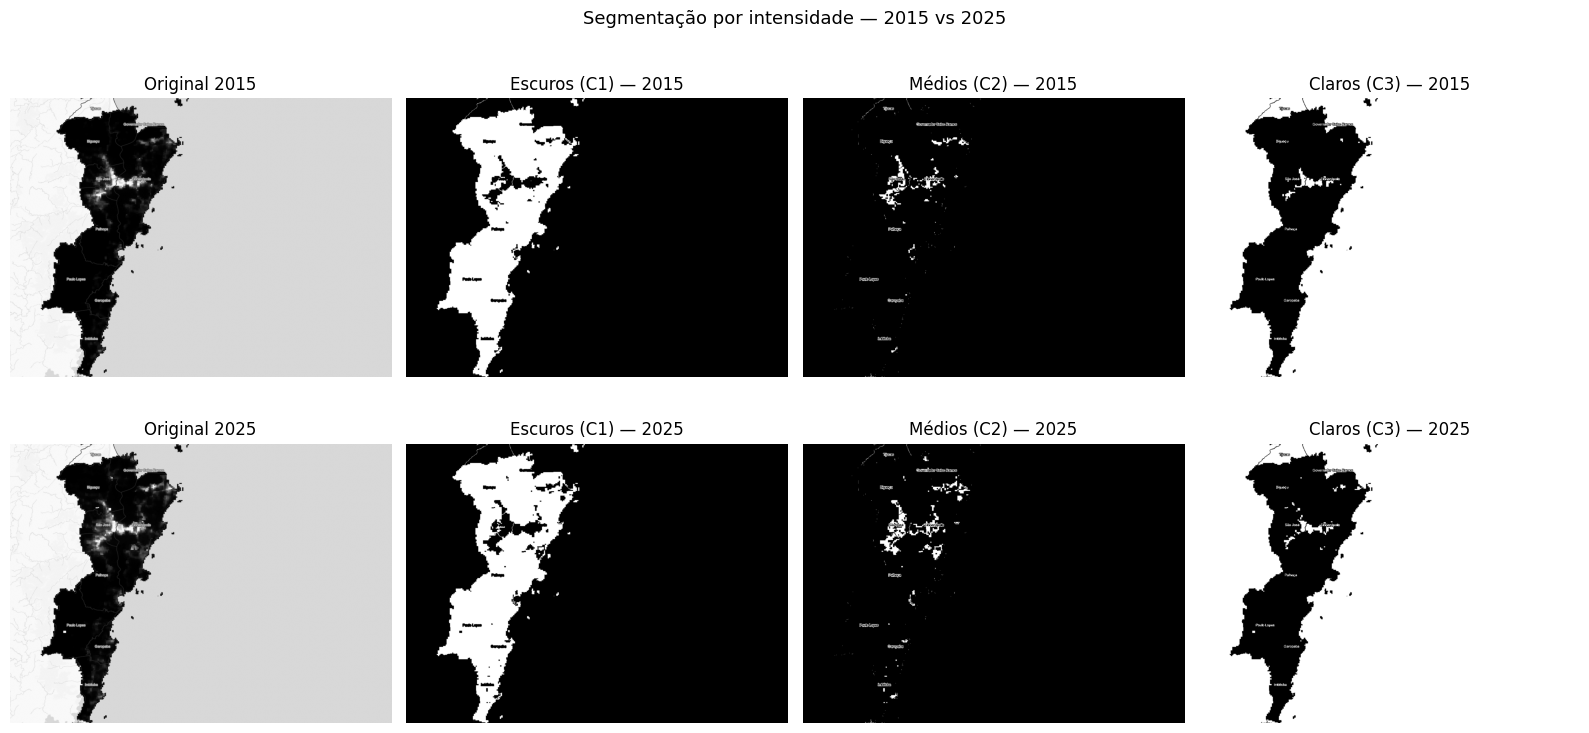

In [15]:
def segmentar(img):
    return {
        'c1': (img >= 0)   & (img < 50),
        'c2': (img >= 50)  & (img < 150),
        'c3': (img >= 150) & (img <= 255),
    }


img_2015 = imagens[0]
img_2025 = imagens[-1]
seg_2015 = segmentar(img_2015)
seg_2025 = segmentar(img_2025)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, (ano, img, seg) in enumerate([
    (2015, img_2015, seg_2015),
    (2025, img_2025, seg_2025),
]):
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'Original {ano}')

    for col, (nome, chave) in enumerate([('Escuros (C1)', 'c1'),
                                          ('Médios (C2)',  'c2'),
                                          ('Claros (C3)',  'c3')], start=1):
        axes[row, col].imshow(seg[chave], cmap='gray')
        axes[row, col].set_title(f'{nome} — {ano}')

for ax in axes.flat:
    ax.axis('off')

plt.suptitle('Segmentação por intensidade — 2015 vs 2025', fontsize=13)
plt.tight_layout()
plt.show()

---
## Célula 4 — Evolução temporal da camada 2 (grid de todos os anos)

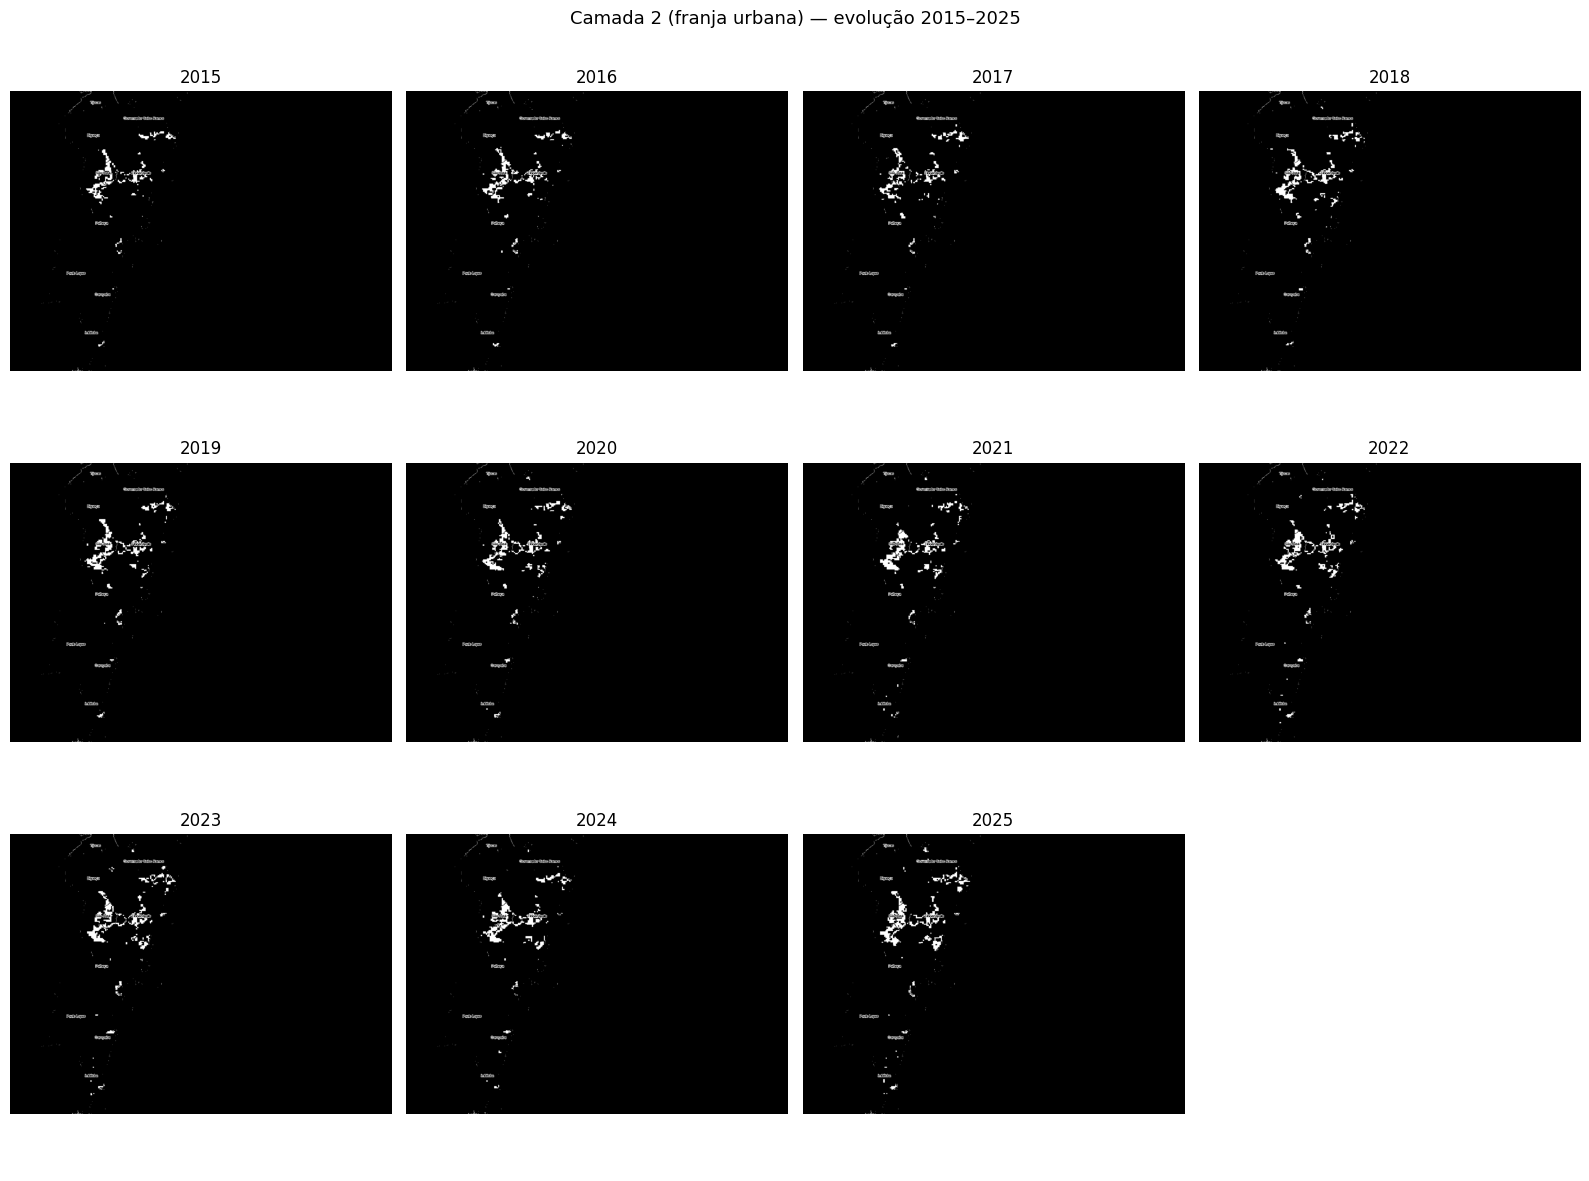

In [16]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, (ano, img) in enumerate(zip(anos, imagens)):
    camada2 = (img >= 50) & (img < 150)
    axes[i].imshow(camada2, cmap='gray')
    axes[i].set_title(str(ano))
    axes[i].axis('off')

axes[-1].axis('off')
plt.suptitle('Camada 2 (franja urbana) — evolução 2015–2025', fontsize=13)
plt.tight_layout()
plt.show()

---
## Célula 5 — Área da camada 2 ao longo dos anos

> Identifica o crescimento da parte urbana. Também computa crescimento % das três camadas
> entre 2015 e 2025

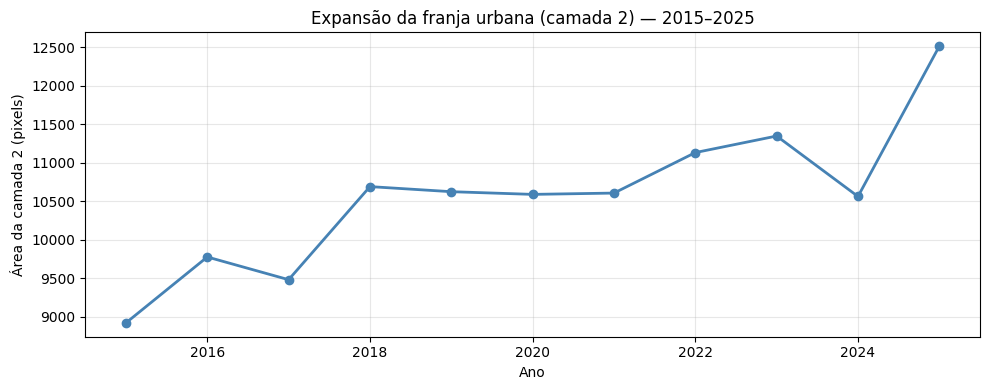

Crescimento camada 1 (escuros): -2.8%
Crescimento camada 2 (médios):  +40.3%
Crescimento camada 3 (claros):  +0.1%


In [17]:
areas_c1, areas_c2, areas_c3 = [], [], []

for img in imagens:
    seg = segmentar(img)
    areas_c1.append(int(np.sum(seg['c1'])))
    areas_c2.append(int(np.sum(seg['c2'])))
    areas_c3.append(int(np.sum(seg['c3'])))

plt.figure(figsize=(10, 4))
plt.plot(anos, areas_c2, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Ano')
plt.ylabel('Área da camada 2 (pixels)')
plt.title('Expansão da franja urbana (camada 2) — 2015–2025')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

def crescimento_pct(a_ini, a_fim):
    return ((a_fim - a_ini) / a_ini) * 100 if a_ini > 0 else float('nan')

print(f"Crescimento camada 1 (escuros): {crescimento_pct(areas_c1[0], areas_c1[-1]):+.1f}%")
print(f"Crescimento camada 2 (médios):  {crescimento_pct(areas_c2[0], areas_c2[-1]):+.1f}%")
print(f"Crescimento camada 3 (claros):  {crescimento_pct(areas_c3[0], areas_c3[-1]):+.1f}%")

---
## Célula 6 — Diferença de intensidade 2025 − 2015

> Mapa de calor seismic: vermelho = ficou mais claro (mais luz), azul = ficou mais escuro.

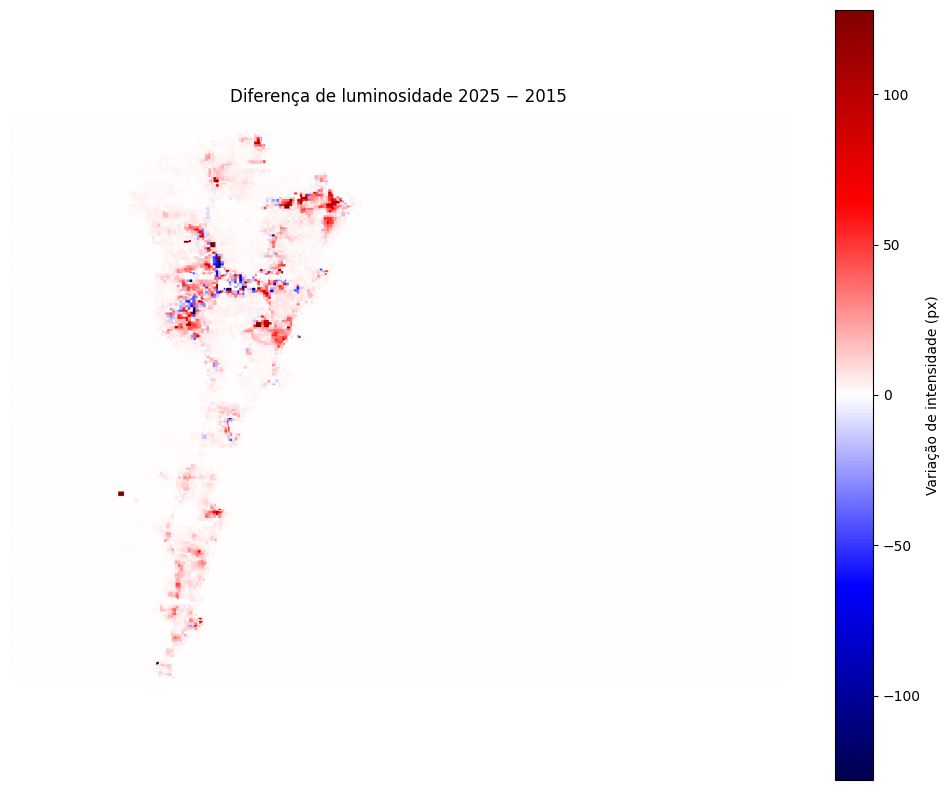

In [18]:
diferenca = img_2025.astype(np.int16) - img_2015.astype(np.int16)

plt.figure(figsize=(10, 8))
plt.imshow(diferenca, cmap='seismic', vmin=-128, vmax=128)
plt.colorbar(label='Variação de intensidade (px)')
plt.title('Diferença de luminosidade 2025 − 2015')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Célula 7 — Clusters DBSCAN com cores (evolução 2015–2025)

2015: 3 clusters | tamanhos: [6307, 1012, 681]
2016: 3 clusters | tamanhos: [6543, 1052, 1012]
2017: 3 clusters | tamanhos: [6082, 1012, 768]
2018: 2 clusters | tamanhos: [6988, 1012]
2019: 3 clusters | tamanhos: [7056, 1011, 719]
2020: 3 clusters | tamanhos: [6612, 1013, 881]
2021: 3 clusters | tamanhos: [6500, 1019, 820]
2022: 4 clusters | tamanhos: [6667, 1013, 931, 858]
2023: 4 clusters | tamanhos: [6756, 1347, 1019, 827]
2024: 3 clusters | tamanhos: [6785, 1011, 710]
2025: 4 clusters | tamanhos: [7602, 1805, 1085, 1048]


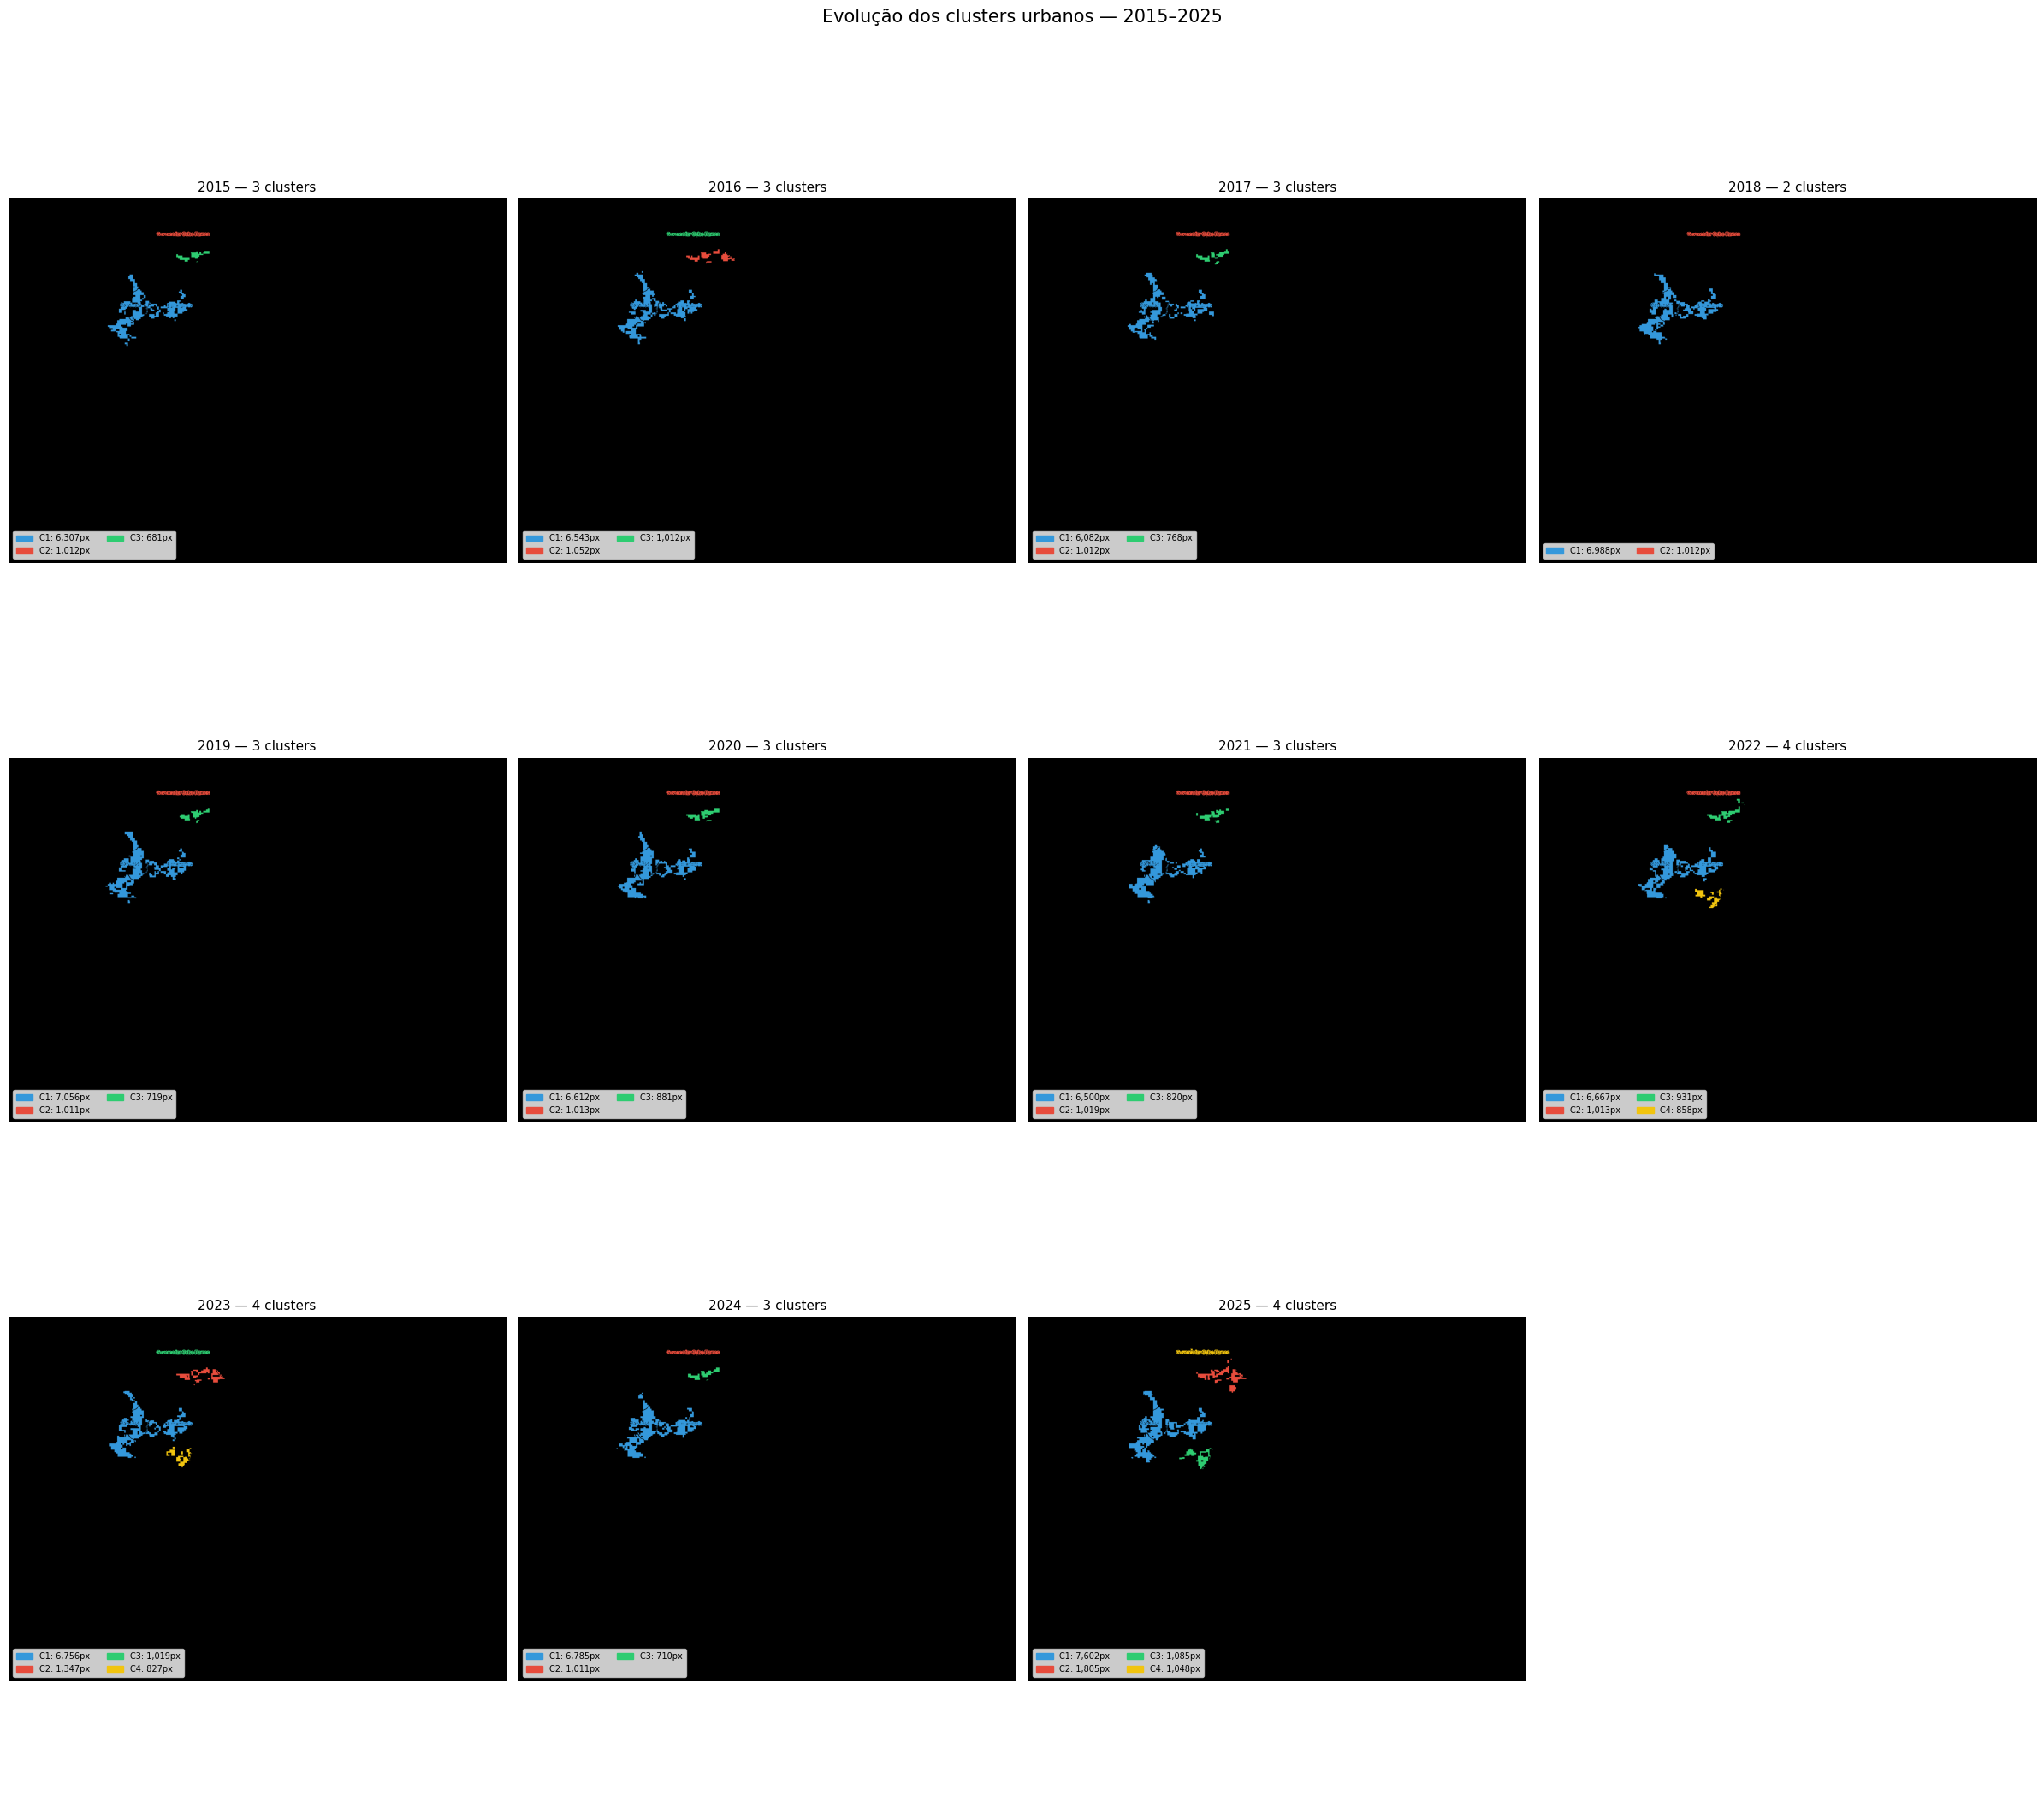

In [19]:
CORES = [
    [52,  152, 219], [231, 76,  60],  [46,  204, 113], [241, 196, 15],
    [155, 89,  182], [230, 126, 34],  [26,  188, 156], [236, 240, 241],
    [22,  160, 133], [192, 57,  43],  [142, 68,  173], [39,  174, 96],
    [41,  128, 185], [243, 156, 18],  [189, 195, 199], [127, 140, 141],
    [44,  62,  80],  [211, 84,  0],   [39,  174, 96],  [93,  173, 226],
    [250, 219, 216], [169, 223, 191], [250, 215, 160], [215, 189, 226],
    [174, 214, 241], [169, 204, 227], [100, 181, 246], [255, 138, 101],
    [102, 187, 106], [255, 241, 118],
]

kernel = np.ones((1, 1), np.uint8)
clusters_por_ano = {}

for i, ano in enumerate(anos):
    img_limpa = cv2.morphologyEx(imagens[i], cv2.MORPH_OPEN, kernel, iterations=2)
    mascara   = (img_limpa >= 50) & (img_limpa < 215)
    coords    = np.column_stack(np.where(mascara))

    if len(coords) == 0:
        print(f"{ano}: sem pixels")
        continue

    labels   = DBSCAN(eps=8, min_samples=30).fit_predict(coords)
    clusters = [
        coords[labels == lbl]
        for lbl in set(labels)
        if lbl != -1 and (labels == lbl).sum() >= 600
    ]
    clusters = sorted(clusters, key=len, reverse=True)
    clusters_por_ano[ano] = clusters
    print(f"{ano}: {len(clusters)} clusters | tamanhos: {[len(c) for c in clusters]}")


anos_disp = sorted(clusters_por_ano.keys())
n_anos    = len(anos_disp)
cols, rows = 4, math.ceil(n_anos / 4)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 7))
axes = axes.flatten()

for idx, ano in enumerate(anos_disp):
    clusters = clusters_por_ano[ano]
    img_ref  = imagens[anos.index(ano)]
    mapa     = np.zeros((*img_ref.shape, 3), dtype=np.uint8)

    for ci, cluster in enumerate(clusters):
        mapa[cluster[:, 0], cluster[:, 1]] = CORES[ci % len(CORES)]

    axes[idx].imshow(mapa)
    axes[idx].set_title(f'{ano} — {len(clusters)} clusters', fontsize=11)
    axes[idx].axis('off')

    legenda = [
        Patch(color=[c / 255 for c in CORES[ci % len(CORES)]],
              label=f'C{ci+1}: {len(clusters[ci]):,}px')
        for ci in range(len(clusters))
    ]
    axes[idx].legend(handles=legenda, loc='lower left', fontsize=7,
                     framealpha=0.8, facecolor='white', ncol=2)

for j in range(n_anos, len(axes)):
    axes[j].axis('off')

plt.suptitle('Evolução dos clusters urbanos — 2015–2025', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---
## Célula 8 — Distância mínima entre os dois maiores clusters ao longo do tempo

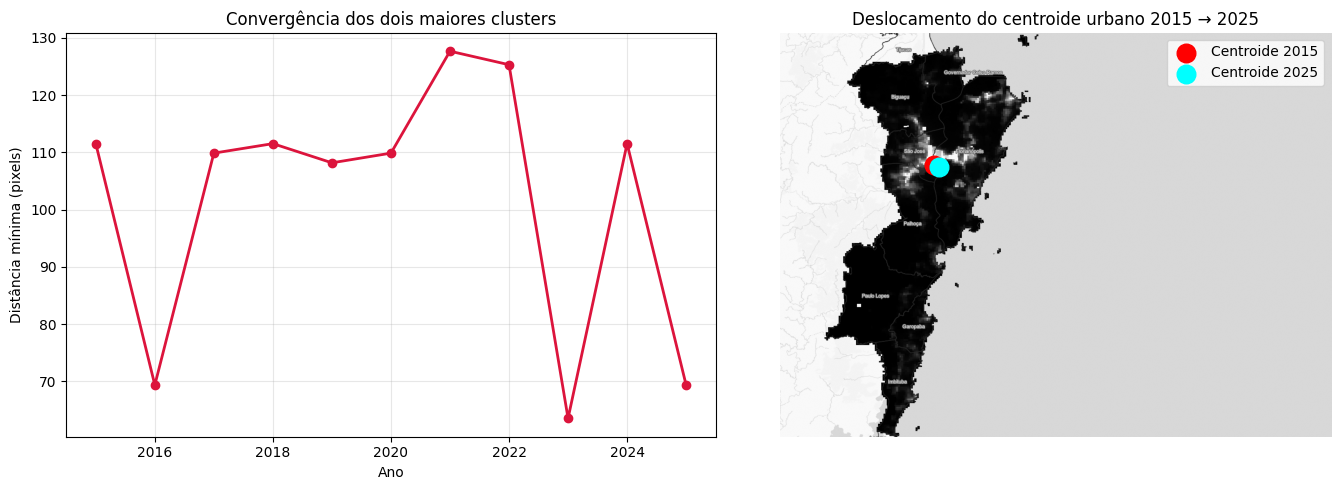

Centroide 2015: y=289.0, x=336.4
Centroide 2025: y=292.4, x=347.5
Magnitude do deslocamento: 11.6 px
Distância 2015: 111.5 px  →  Distância 2025: 69.4 px


In [20]:
anos_dist, distancias = [], []

for ano in anos_disp:
    clusters = clusters_por_ano[ano]
    if len(clusters) < 2:
        continue
    dist = euclidean_distances(clusters[0], clusters[1]).min()
    anos_dist.append(ano)
    distancias.append(dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(anos_dist, distancias, marker='o', color='crimson', linewidth=2)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Distância mínima (pixels)')
axes[0].set_title('Convergência dos dois maiores clusters')
axes[0].grid(alpha=0.3)

coords_2015 = np.column_stack(np.where((imagens[0]  >= 50) & (imagens[0]  < 150)))
coords_2025 = np.column_stack(np.where((imagens[-1] >= 50) & (imagens[-1] < 150)))

c2015 = coords_2015.mean(axis=0)  # (y, x)
c2025 = coords_2025.mean(axis=0)

axes[1].imshow(imagens[-1], cmap='gray')
axes[1].scatter(c2015[1], c2015[0], c='red',  s=180, zorder=5, label='Centroide 2015')
axes[1].scatter(c2025[1], c2025[0], c='cyan', s=180, zorder=5, label='Centroide 2025')
axes[1].annotate('', xy=(c2025[1], c2025[0]), xytext=(c2015[1], c2015[0]),
                 arrowprops=dict(arrowstyle='->', color='yellow', lw=2))
axes[1].legend()
axes[1].set_title('Deslocamento do centroide urbano 2015 → 2025')
axes[1].axis('off')

plt.tight_layout()
plt.show()

deslocamento = np.linalg.norm(c2025 - c2015)
print(f"Centroide 2015: y={c2015[0]:.1f}, x={c2015[1]:.1f}")
print(f"Centroide 2025: y={c2025[0]:.1f}, x={c2025[1]:.1f}")
print(f"Magnitude do deslocamento: {deslocamento:.1f} px")
if len(distancias) >= 2:
    print(f"Distância 2015: {distancias[0]:.1f} px  →  Distância {anos_dist[-1]}: {distancias[-1]:.1f} px")

---
## Célula 9 — Previsão por regressão linear pixel a pixel (2035)

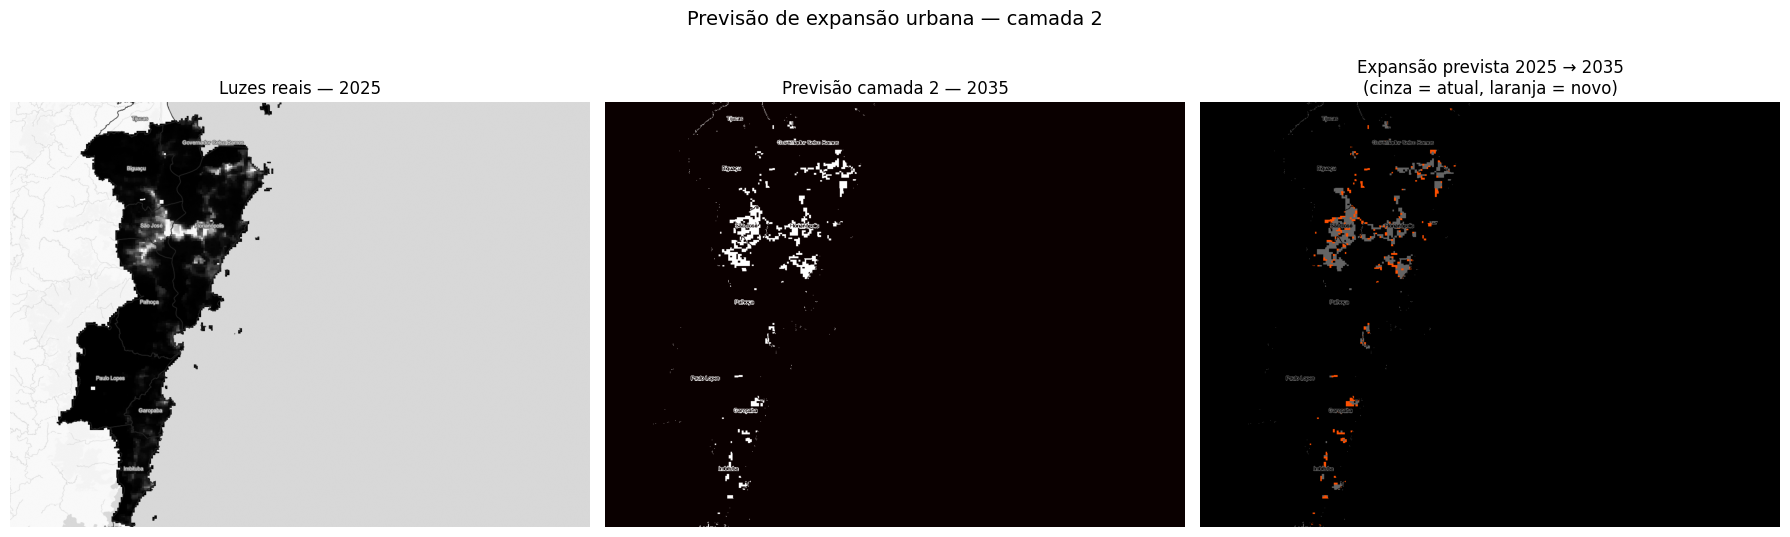


Área camada 2 em 2025:       12,516 pixels
Área camada 2 prevista 2035: 13,860 pixels
Expansão prevista:           3,581 pixels novos


In [21]:
def prever_expansao_pixel(imagens_por_ano, anos, ano_alvo=2035):

    anos_arr = np.array(anos, dtype=np.float32)
    ano_alvo = float(ano_alvo)
    stack = np.stack(imagens_por_ano, axis=0).astype(np.float32) 

    x_mean = anos_arr.mean()
    y_mean = stack.mean(axis=0)                                     
    x_diff = anos_arr - x_mean                                      

    num = np.einsum('t,thw->hw', x_diff, stack - y_mean)        
    denom = (x_diff ** 2).sum()                                    

    a = num / denom                                           
    b = y_mean - a * x_mean                                    

    mapa = a * ano_alvo + b
    mapa[stack.max(axis=0) <= 5] = 0                                   

    return np.clip(mapa, 0, 255).astype(np.uint8)

mapa_2035 = prever_expansao_pixel(imagens, anos, ano_alvo=2035)

camada2_2025 = (imagens[-1] >= 50) & (imagens[-1] < 150)
camada2_prevista = (mapa_2035  >= 50) & (mapa_2035  < 150)
novos_pixels = camada2_prevista & ~camada2_2025       

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(imagens[-1], cmap='gray')
axes[0].set_title('Luzes reais — 2025')
axes[0].axis('off')

axes[1].imshow(camada2_prevista, cmap='hot')
axes[1].set_title('Previsão camada 2 — 2035')
axes[1].axis('off')

comparacao = np.zeros((*camada2_2025.shape, 3), dtype=np.uint8)
comparacao[camada2_2025] = [100, 100, 100]  
comparacao[novos_pixels] = [255, 80,  0]    
axes[2].imshow(comparacao)
axes[2].set_title('Expansão prevista 2025 → 2035\n(cinza = atual, laranja = novo)')
axes[2].axis('off')

plt.suptitle('Previsão de expansão urbana — camada 2', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nÁrea camada 2 em 2025:       {camada2_2025.sum():,} pixels")
print(f"Área camada 2 prevista 2035: {camada2_prevista.sum():,} pixels")
print(f"Expansão prevista:           {novos_pixels.sum():,} pixels novos")

---
## Célula 10 — Previsão da camada 3 (núcleo consolidado) em 2035

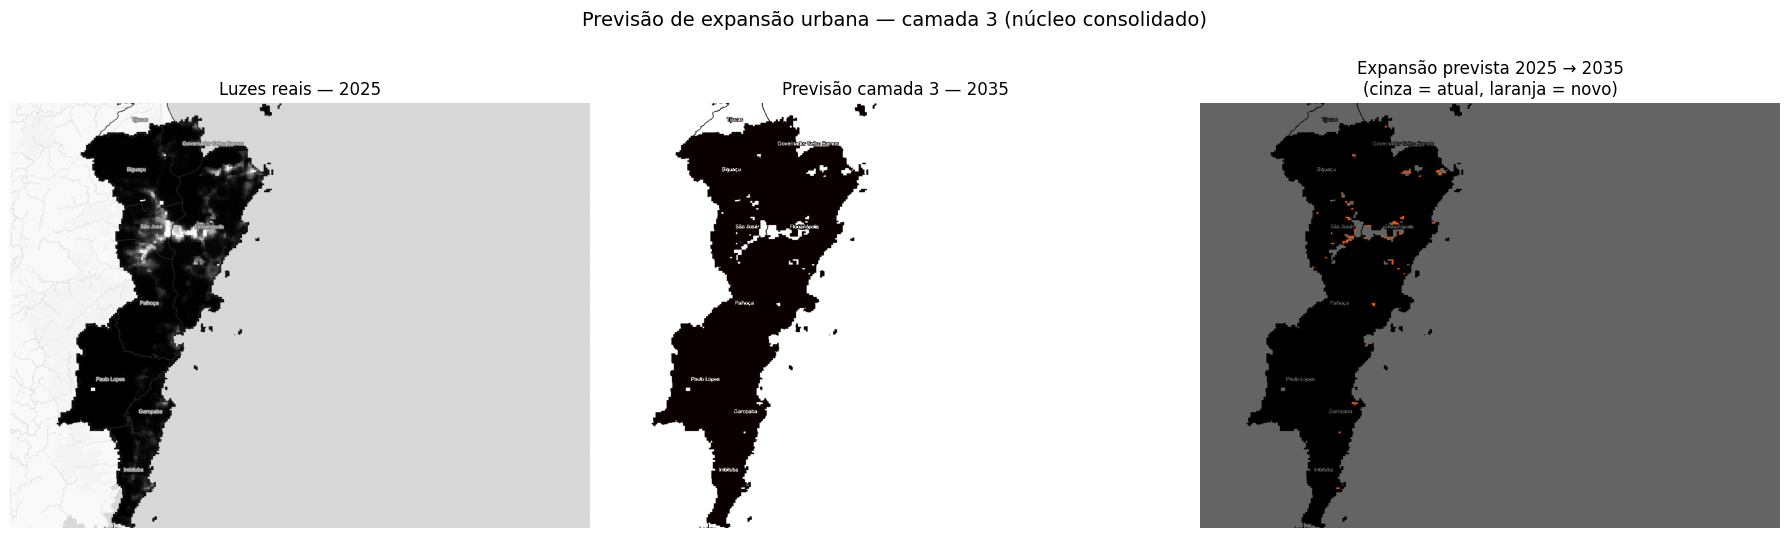


Área camada 3 em 2025:       907,806 pixels
Área camada 3 prevista 2035: 908,288 pixels
Expansão prevista:           1,019 pixels novos


In [22]:
camada3_2025 = imagens[-1] >= 150
camada3_prevista = mapa_2035  >= 150
novos_c3 = camada3_prevista & ~camada3_2025

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(imagens[-1], cmap='gray')
axes[0].set_title('Luzes reais — 2025')
axes[0].axis('off')

axes[1].imshow(camada3_prevista, cmap='hot')
axes[1].set_title('Previsão camada 3 — 2035')
axes[1].axis('off')

comparacao = np.zeros((*camada3_2025.shape, 3), dtype=np.uint8)
comparacao[camada3_2025] = [100, 100, 100]
comparacao[novos_c3]     = [255, 80,  0]
axes[2].imshow(comparacao)
axes[2].set_title('Expansão prevista 2025 → 2035\n(cinza = atual, laranja = novo)')
axes[2].axis('off')

plt.suptitle('Previsão de expansão urbana — camada 3 (núcleo consolidado)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nÁrea camada 3 em 2025:       {camada3_2025.sum():,} pixels")
print(f"Área camada 3 prevista 2035: {camada3_prevista.sum():,} pixels")
print(f"Expansão prevista:           {novos_c3.sum():,} pixels novos")

---
## Célula 11 — Clusters sobrepostos à previsão 2035

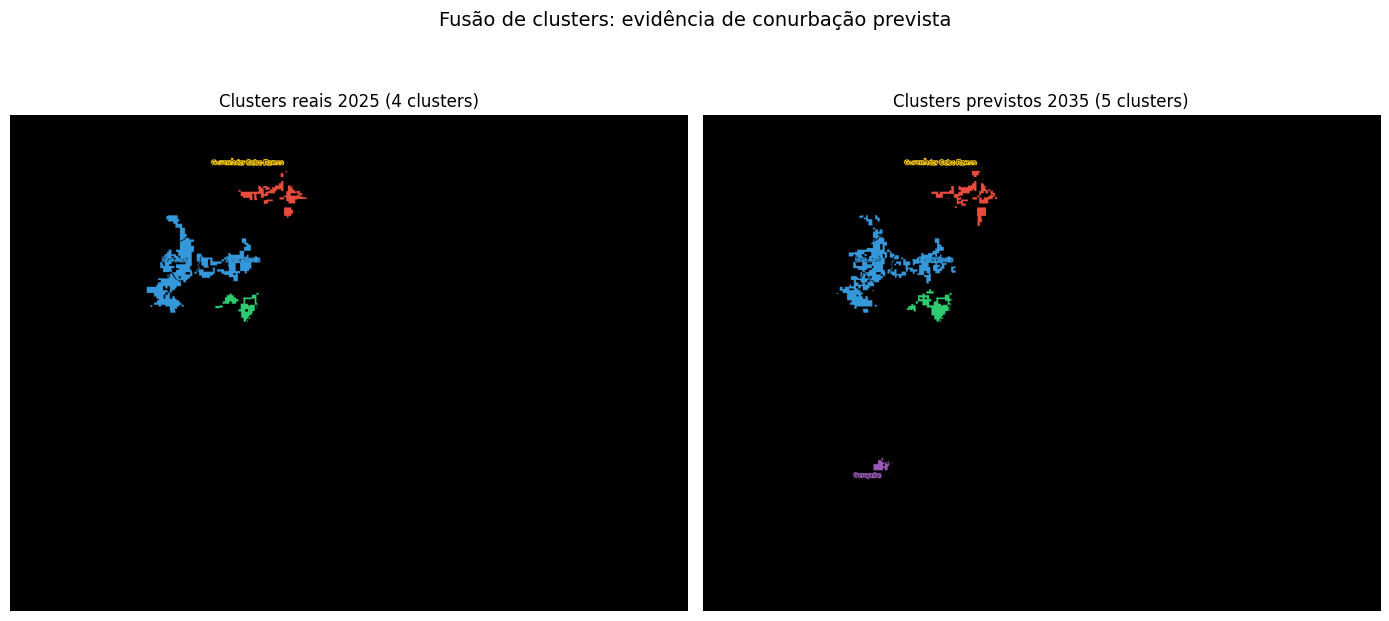

Clusters em 2025: 4
Clusters previstos em 2035: 5


In [23]:
# Reutiliza os mesmos parâmetros DBSCAN da Célula 7 para comparabilidade
mascara_prev = (mapa_2035 >= 50) & (mapa_2035 < 210)
coords_prev  = np.column_stack(np.where(mascara_prev))

labels_prev = DBSCAN(eps=8, min_samples=30).fit_predict(coords_prev)
clusters_prev = [
    coords_prev[labels_prev == lbl]
    for lbl in set(labels_prev)
    if lbl != -1 and (labels_prev == lbl).sum() >= 600
]
clusters_prev = sorted(clusters_prev, key=len, reverse=True)

mapa_vis = np.zeros((*mapa_2035.shape, 3), dtype=np.uint8)
for ci, cluster in enumerate(clusters_prev):
    mapa_vis[cluster[:, 0], cluster[:, 1]] = CORES[ci % len(CORES)]

# Comparação: clusters 2025 vs clusters 2035 previstos
clusters_2025 = clusters_por_ano.get(2025, [])
mapa_2025_vis = np.zeros((*imagens[-1].shape, 3), dtype=np.uint8)
for ci, cluster in enumerate(clusters_2025):
    mapa_2025_vis[cluster[:, 0], cluster[:, 1]] = CORES[ci % len(CORES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(mapa_2025_vis)
axes[0].set_title(f'Clusters reais 2025 ({len(clusters_2025)} clusters)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(mapa_vis)
axes[1].set_title(f'Clusters previstos 2035 ({len(clusters_prev)} clusters)', fontsize=12)
axes[1].axis('off')

plt.suptitle('Fusão de clusters: evidência de conurbação prevista', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Clusters em 2025: {len(clusters_2025)}")
print(f"Clusters previstos em 2035: {len(clusters_prev)}")
if len(clusters_2025) > len(clusters_prev):
    print("Redução no número de clusters: clusters se fundiram (conurbação em curso)")
elif len(clusters_2025) == len(clusters_prev):
    print("Número estável de clusters: crescimento sem fusão no período projetado")

---
## Célula 12 — Detecção de rodovia entre as cidades

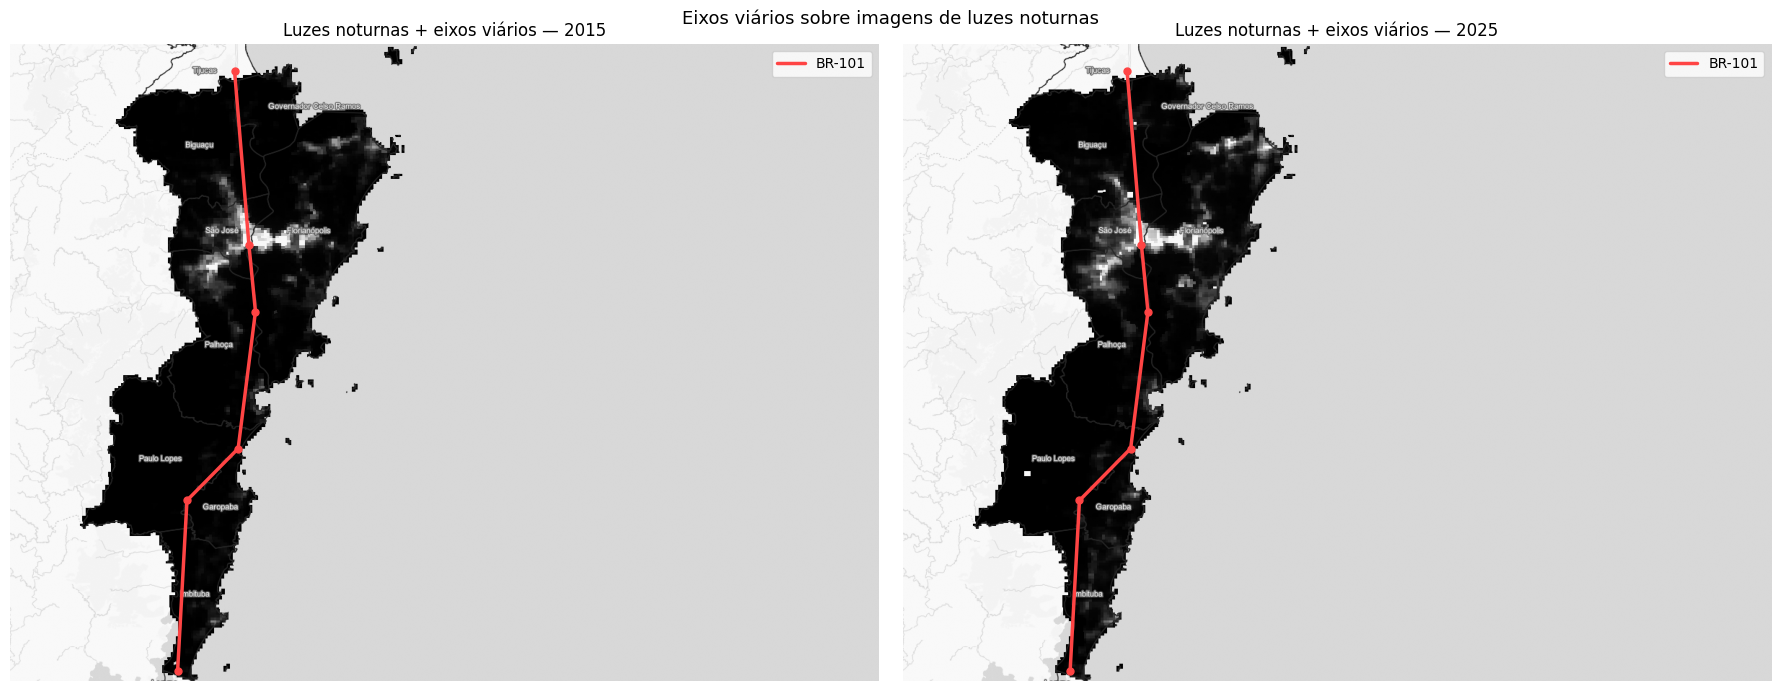

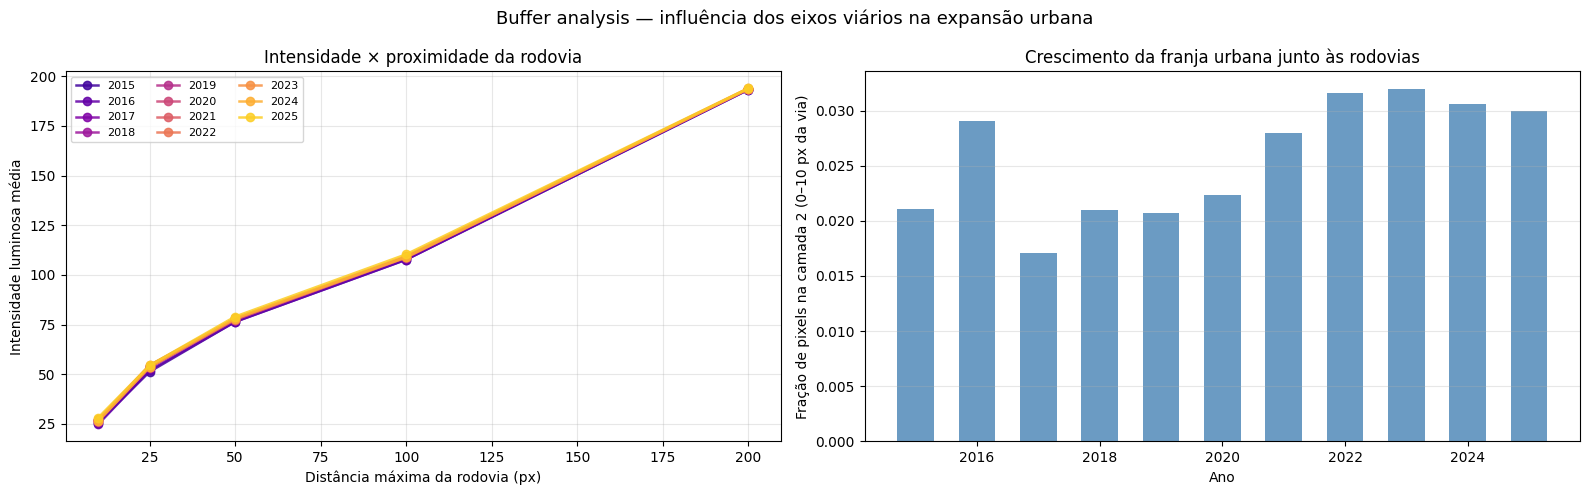

Fração de pixels c2 na faixa 0–10 px da rodovia por ano:
  2015: 0.021 (2.1%)
  2016: 0.029 (2.9%)
  2017: 0.017 (1.7%)
  2018: 0.021 (2.1%)
  2019: 0.021 (2.1%)
  2020: 0.022 (2.2%)
  2021: 0.028 (2.8%)
  2022: 0.032 (3.2%)
  2023: 0.032 (3.2%)
  2024: 0.031 (3.1%)
  2025: 0.030 (3.0%)


In [24]:

rodovias = {
    'BR-101': np.array([[311, 36], [331, 278], [340, 370], [316, 560], [245, 632], [232, 869]])
}

CORES_VIA = {'BR-101': '#FF4444'}


def rasterizar_rodovias(shape, rodovias, espessura=2):
    mascara = np.zeros(shape, dtype=np.uint8)
    for pontos in rodovias.values():
        for k in range(len(pontos) - 1):
            p1 = tuple(pontos[k].astype(int))
            p2 = tuple(pontos[k + 1].astype(int))
            cv2.line(mascara, p1, p2, 255, espessura)
    return mascara


mascara_rod = rasterizar_rodovias((h_ref, w_ref), rodovias, espessura=3)
dist_rodovia = distance_transform_edt(mascara_rod == 0)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (ano, img) in zip(axes, [(anos[0], imagens[0]), (anos[-1], imagens[-1])]):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    for nome, pontos in rodovias.items():
        ax.plot(pontos[:, 0], pontos[:, 1],
                color=CORES_VIA.get(nome, 'yellow'),
                linewidth=2.5, label=nome,
                solid_capstyle='round', solid_joinstyle='round')
        ax.scatter(pontos[:, 0], pontos[:, 1],
                   color=CORES_VIA.get(nome, 'yellow'), s=25, zorder=5)
    ax.legend(loc='upper right', framealpha=0.8)
    ax.set_title(f'Luzes noturnas + eixos viários — {ano}')
    ax.axis('off')

plt.suptitle('Eixos viários sobre imagens de luzes noturnas', fontsize=13)
plt.tight_layout()
plt.show()


BUFFERS_PX = [0, 10, 25, 50, 100, 200]

def buffer_analysis(img, dist_map, buffers_px=BUFFERS_PX):
    resultados = []
    for k in range(len(buffers_px) - 1):
        d_min, d_max = buffers_px[k], buffers_px[k + 1]
        zona         = (dist_map >= d_min) & (dist_map < d_max)
        pixels       = img[zona]
        if len(pixels) == 0:
            continue
        resultados.append({
            'buffer_max_px':     d_max,
            'intensidade_media': float(pixels.mean()),
            'area_pixels':       int(len(pixels)),
            'frac_c2':           float(np.mean((pixels >= 50) & (pixels < 150))),
            'frac_c3':           float(np.mean(pixels >= 150)),
        })
    return resultados


resultados_temporais = {
    ano: buffer_analysis(img, dist_rodovia)
    for ano, img in zip(anos, imagens)
}


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cmap_anos = plt.cm.plasma(np.linspace(0.1, 0.9, len(anos)))
for (ano, buffers), cor in zip(resultados_temporais.items(), cmap_anos):
    xs = [b['buffer_max_px']     for b in buffers]
    ys = [b['intensidade_media'] for b in buffers]
    axes[0].plot(xs, ys, marker='o', color=cor,
                 linewidth=1.8, alpha=0.85, label=str(ano))
axes[0].set_xlabel('Distância máxima da rodovia (px)')
axes[0].set_ylabel('Intensidade luminosa média')
axes[0].set_title('Intensidade × proximidade da rodovia')
axes[0].legend(ncol=3, fontsize=8)
axes[0].grid(alpha=0.3)

anos_validos = []
frac_c2_proxima = []
for ano in anos:
    buffers = resultados_temporais[ano]
    faixa   = next((b for b in buffers if b['buffer_max_px'] == 10), None)
    if faixa is not None:
        anos_validos.append(ano)
        frac_c2_proxima.append(faixa['frac_c2'])

axes[1].bar(anos_validos, frac_c2_proxima, color='steelblue', alpha=0.8, width=0.6)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Fração de pixels na camada 2 (0–10 px da via)')
axes[1].set_title('Crescimento da franja urbana junto às rodovias')
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Buffer analysis — influência dos eixos viários na expansão urbana', fontsize=13)
plt.tight_layout()
plt.show()

print('Fração de pixels c2 na faixa 0–10 px da rodovia por ano:')
for ano, frac in zip(anos_validos, frac_c2_proxima):
    print(f'  {ano}: {frac:.3f} ({frac*100:.1f}%)')

---
## Célula 13 — Detecção de conurbação com o passar dos anos

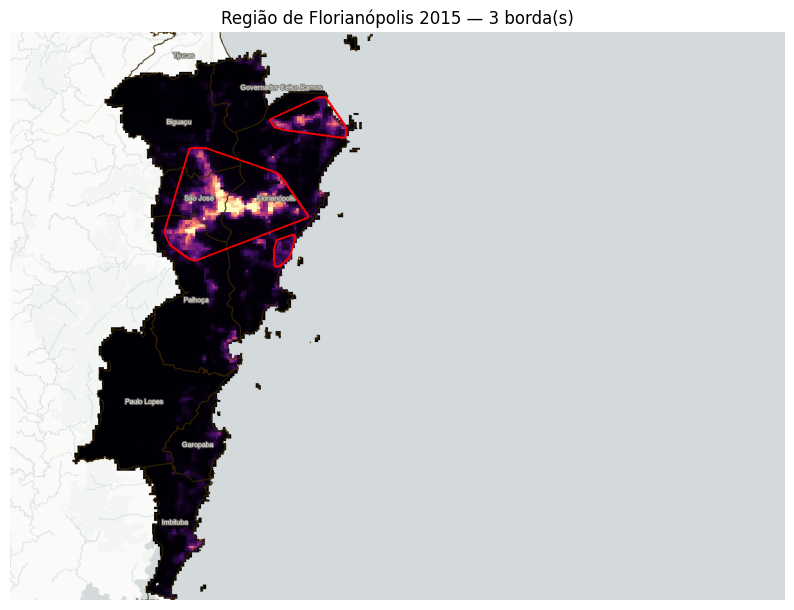

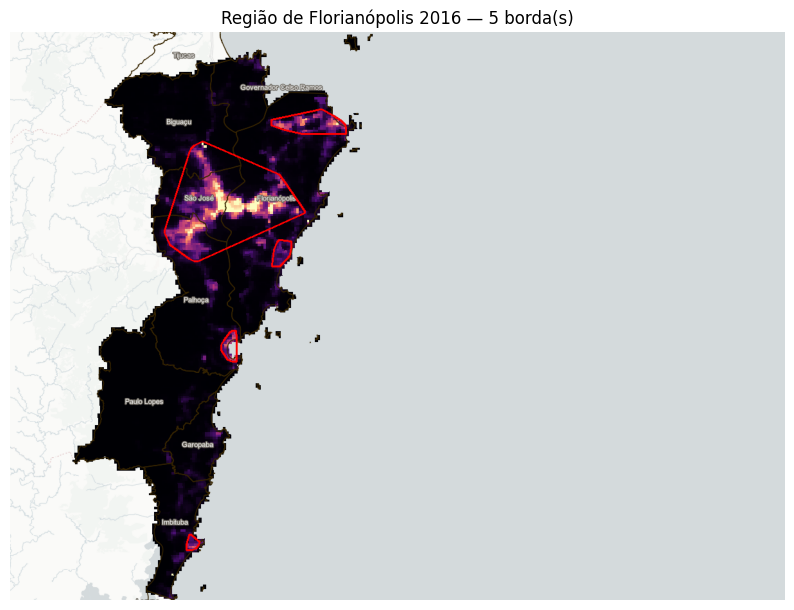

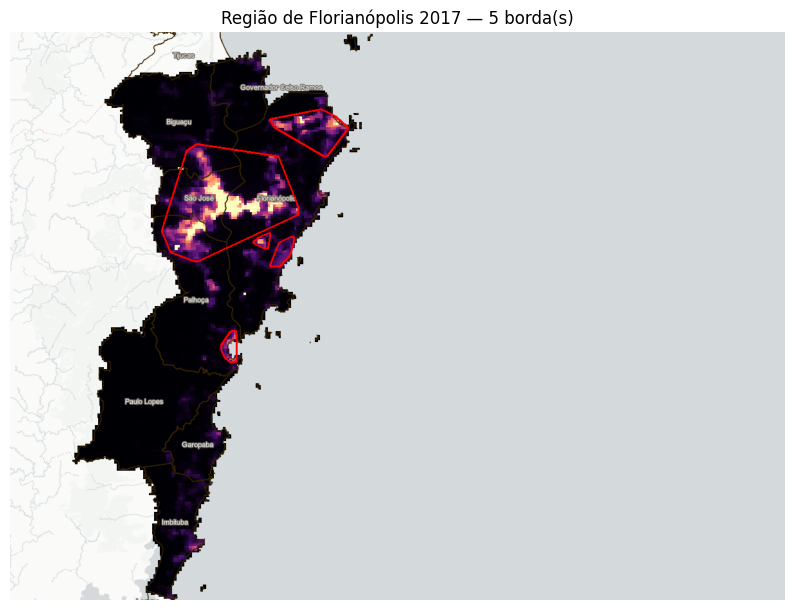

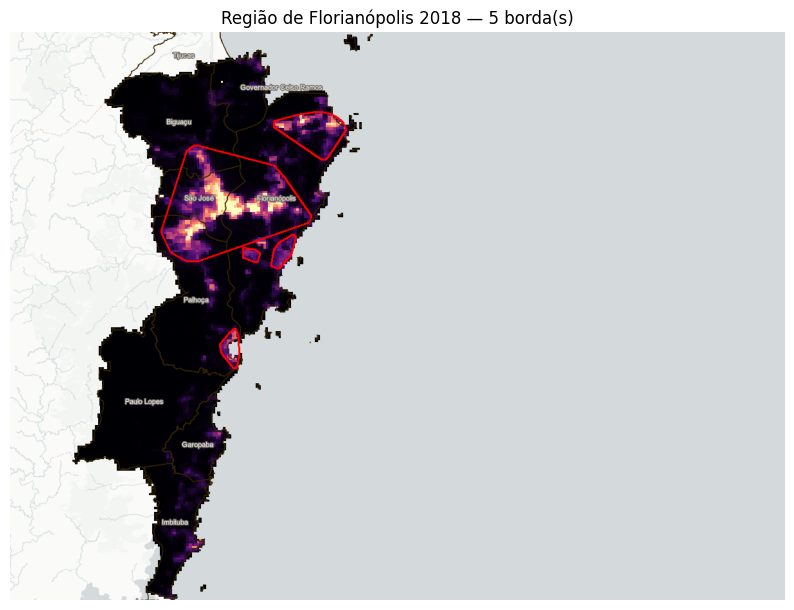

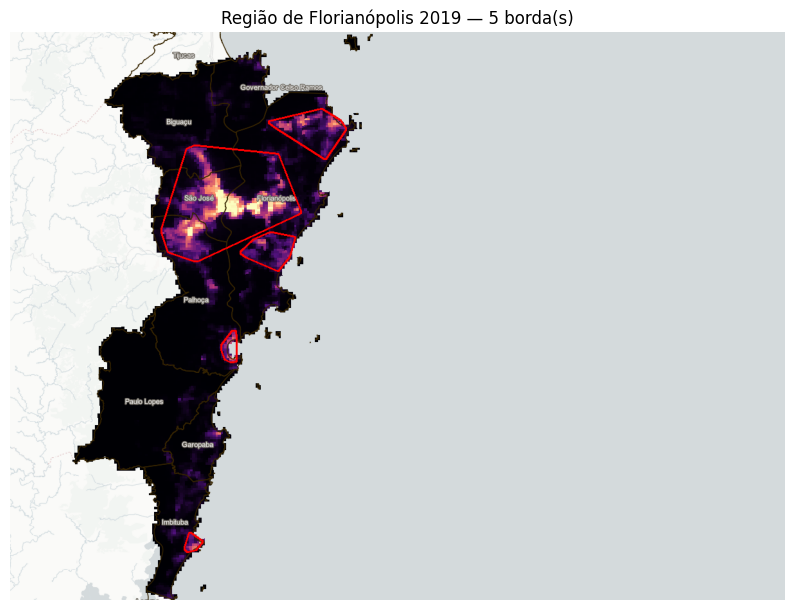

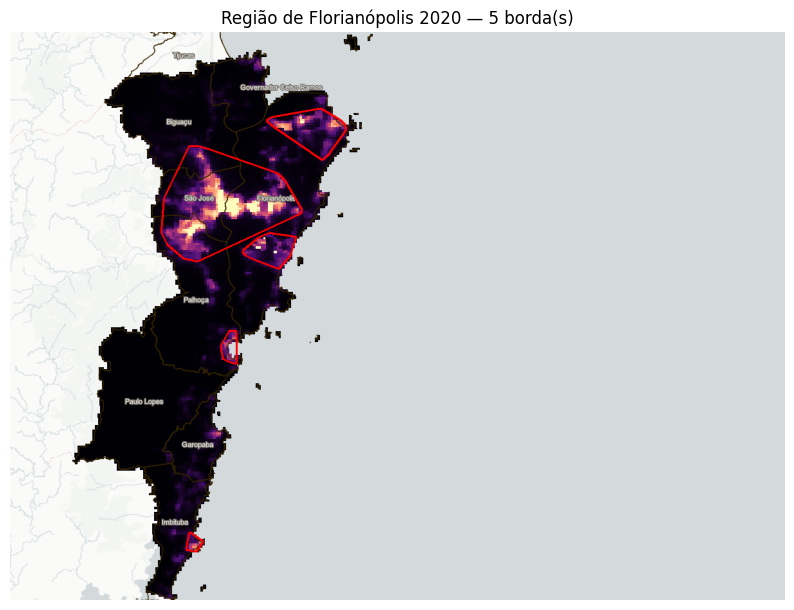

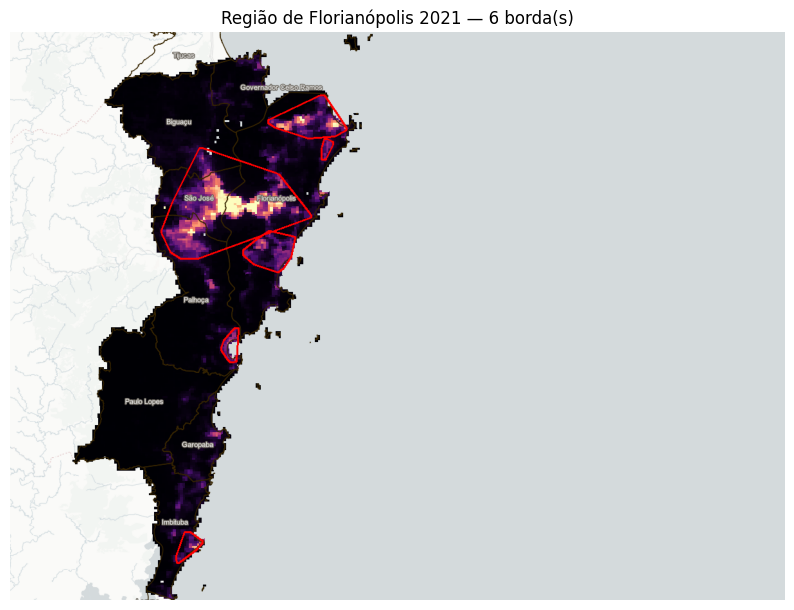

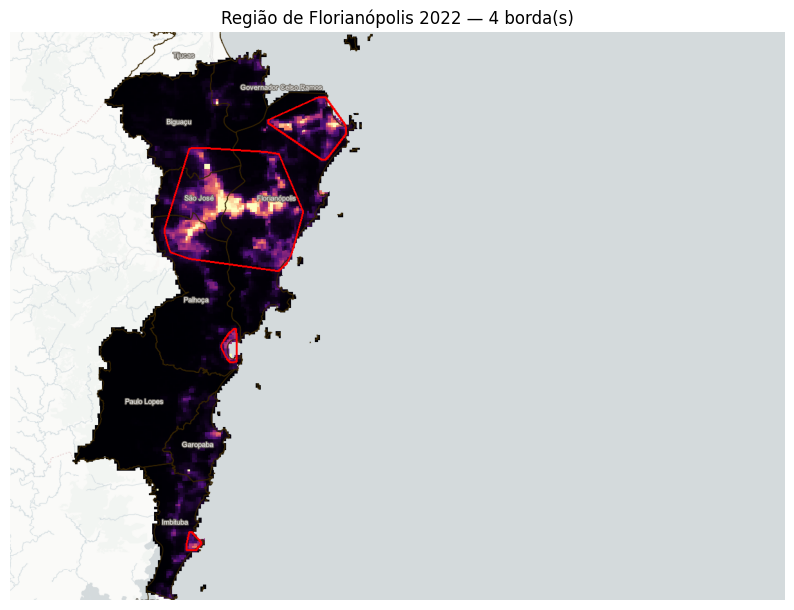

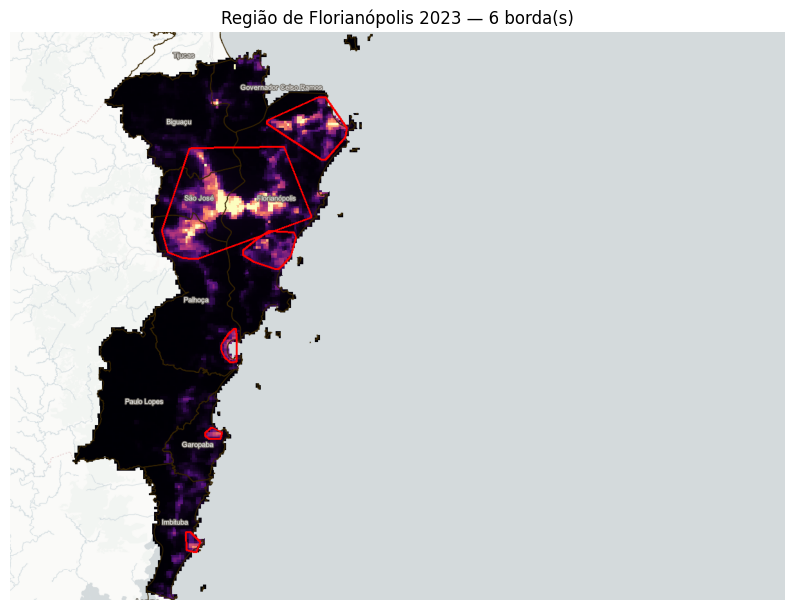

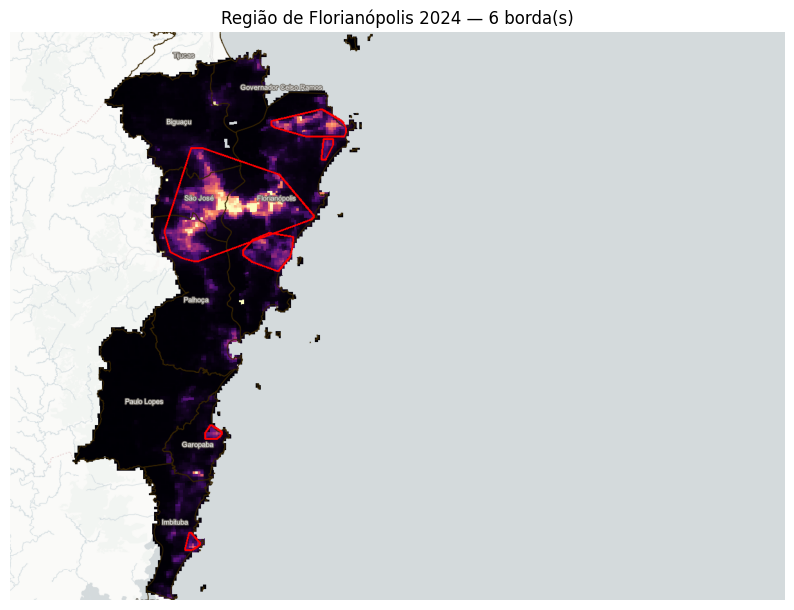

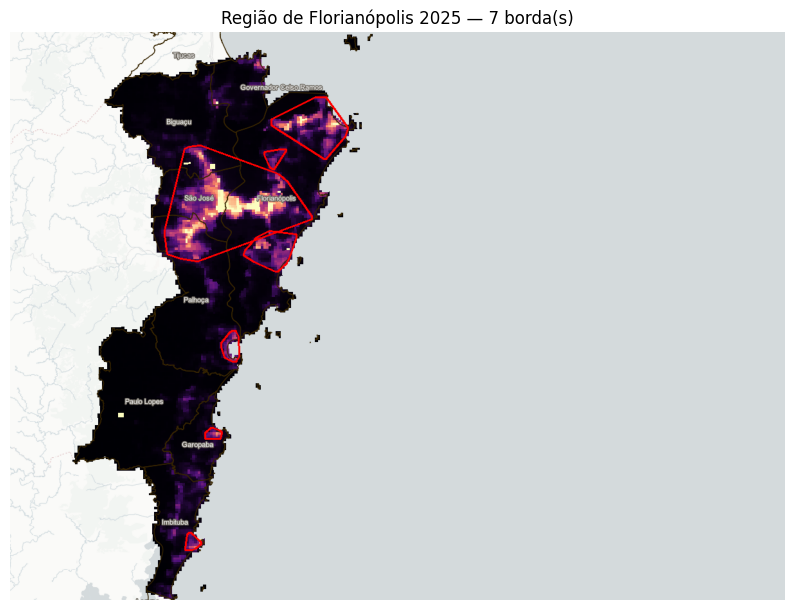

In [25]:
def carregar_imagem_rgb(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"Imagem não encontrada: {path}")

    if img.ndim == 2:
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    if img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img


def detectar_e_desenhar_conurbacoes(
    img,
    limiar_v=80,
    limiar_s=25,
    limiar_diff=20,
    eps=6,
    min_samples=20,
    area_min=300,
    fill_min=0.18
):
    if img.ndim == 3:
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img.copy()
        hsv = cv2.cvtColor(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB), cv2.COLOR_RGB2HSV)

    v = hsv[:, :, 2]
    s = hsv[:, :, 1]

    rgb_diff = img.max(axis=2) - img.min(axis=2)

    mask_luz = (
        (v >= limiar_v) &
        ((s >= limiar_s) | (rgb_diff >= limiar_diff))
    )

    mask = (mask_luz.astype(np.uint8) * 255)
    mask = cv2.medianBlur(mask, 3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)

    coords = np.column_stack(np.where(mask > 0))

    saida = img.copy()
    num_clusters = 0

    if len(coords) == 0:
        return saida, mask, num_clusters

    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(coords)

    for label in set(labels):
        if label == -1:
            continue

        pontos = coords[labels == label]

        if len(pontos) < area_min:
            continue

        pontos_xy = pontos[:, [1, 0]].astype(np.int32)

        x, y, w, h = cv2.boundingRect(pontos_xy)
        bbox_area = max(w * h, 1)
        fill_ratio = len(pontos_xy) / bbox_area

        if fill_ratio < fill_min:
            continue

        if len(pontos_xy) < 3:
            continue

        hull = cv2.convexHull(pontos_xy)
        cv2.polylines(saida, [hull], True, (255, 0, 0), 2)
        num_clusters += 1

    return saida, mask, num_clusters


anos = []
num_clusters = []

for ano in range(2015, 2026):
    img = carregar_imagem_rgb(f'assets/Florianopolis{ano}.png')

    resultado, mascara, clusters = detectar_e_desenhar_conurbacoes(
        img,
        limiar_v=85,        
        limiar_s=28,        
        limiar_diff=18,     
        eps=6,
        min_samples=20,
        area_min=300,
        fill_min=0.20       
    )

    anos.append(ano)
    num_clusters.append(clusters)

    plt.figure(figsize=(10, 8))
    plt.imshow(resultado)
    plt.title(f'Região de Florianópolis {ano} — {clusters} borda(s)')
    plt.axis('off')
    plt.show()